In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_regression

In [2]:
x,y = make_regression(n_samples=100,n_features=1,n_informative=1,n_targets=1,noise=20,random_state=13)

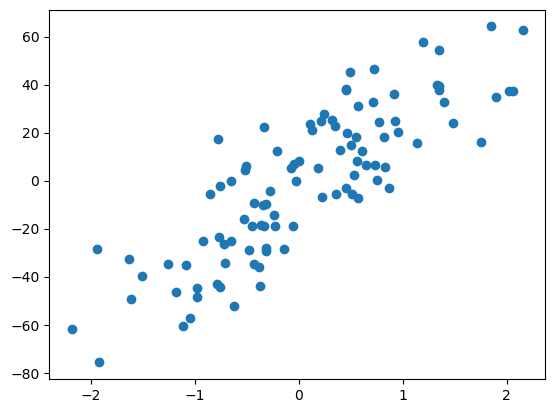

In [3]:
import matplotlib.pyplot as plt
plt.scatter(x,y)

In [4]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [5]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [6]:
y_pred =lr.predict(x_test)

In [7]:
from sklearn.metrics import r2_score
r2_score(y_test , y_pred)

0.6345158782661012

In [8]:
lr.intercept_

np.float64(-2.2710144261783825)

In [9]:
lr.coef_

array([28.12597332])

In [11]:
from sklearn.linear_model import Ridge
R = Ridge(alpha=10)
R.fit(x_train,y_train)
y_pred_1 =R.predict(x_test)

In [12]:
r2_score(y_test,y_pred_1)

0.6387892505532382

In [13]:
R.intercept_

np.float64(-2.1047489001173156)

In [15]:
R.coef_

array([24.84312743])

In [16]:
rr1 = Ridge(alpha=100)
rr1.fit(x_train,y_train)

Ridge(alpha=100)

In [17]:
y_pred_2 = rr1.predict(x_test)

In [18]:
rr1.intercept_

np.float64(-1.4601506973989027)

In [19]:
rr1.coef_

array([12.11579539])

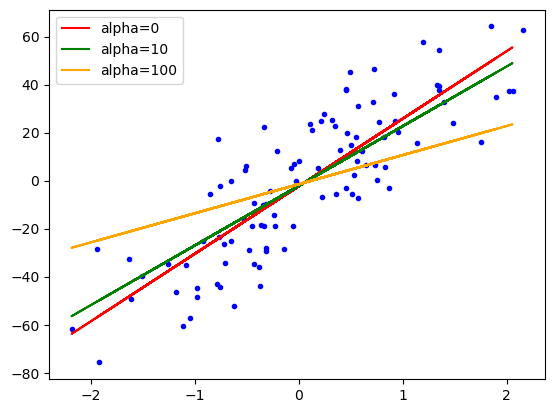

In [22]:
plt.plot(x,y,'b.')
plt.plot(x_train,lr.predict(x_train),color='red' , label = 'alpha=0')
plt.plot(x_train,R.predict(x_train),color='green' , label = 'alpha=10')
plt.plot(x_train,rr1.predict(x_train),color='orange' , label = 'alpha=100')
plt.legend()
plt.show()

In [34]:
class MeraRidge:
    def __init__(self,alpha = 0.1):
        self.m = None
        self.b = None
        self.alpha = alpha
    def fit(self,x_train,y_train):
        num = 0
        den = 0
        for i in range(x_train.shape[0]):
            num = num + (y_train[i] - y_train.mean())*(x_train[i] - x_train.mean())
            den = den + (x_train[i] - x_train.mean())*(x_train[i] - x_train.mean())

            self.m = num/(den + self.alpha)
            self.b = y_train.mean() - self.m*x_train.mean()

        print(self.b , self.m)    

        pass
    def predict(self , x_test):
        pass


In [36]:
reg = MeraRidge(alpha=10)
reg.fit(x_train,y_train)

[-2.1047489] [24.84312743]
